# Double-Top / Double-Bottom — a quantitative teardown
### 10 tickers · 15 years of daily bars · random-day placebo · HAC inference · Bonferroni correction

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Placebo_wins%3F: Yes](https://img.shields.io/badge/Placebo_wins%3F-Yes-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) — same seven beats, every claim carrying its standard error. We test whether confirmed double-top and double-bottom patterns produce a forward return statistically distinguishable from an unconditional random-day bet in the same direction.

> ⚠️ **Not investment advice.** Real data: Yahoo Finance daily bars 2010-01-01 to 2026-06-15. Methods & sources in [`docs/references.md`](../docs/references.md); reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from double_top import data, strategy as st

TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "AMZN", "GOOGL", "JPM", "XOM", "GLD", "IWM"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled_study(cost_bps=0.0, seed=189, **kw):
    """Pool pattern study across all tickers (real cache)."""
    return st.run_pooled_study(
        TICKERS, fetch=False, horizons=(1, 5, 20),
        cost_bps=cost_bps, seed=seed,
        min_bars=10, tolerance=0.04, lookback=120, atr_prominence_mult=0.5,
        **kw
    )

print("real daily cache present:", HAVE_REAL)

from quantlab import analytics, stats


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Max HAC |t| on excess return (pattern − placebo) = **1.39** across 6 tests; Bonferroni threshold 3.0; zero tests survive. |
| **Tradability** | `MIRAGE` | No positive gross excess exists before costs; the break-even transaction cost is below zero. |
| **Placebo wins?** | `YES` | At 5d and 20d, the random-day arm outperforms the confirmed pattern on both double-top and double-bottom. |

> 💡 The patterns see the past clearly — two peaks at a similar high — but they do not predict the future beyond what unconditional market drift already implies.

## 1 · The claim, steelmanned

Let $P_t^{\\text{DT}}$ be an indicator that a confirmed double-top fires at bar $t$ (neckline break below the intervening trough), and $r_{t,h}$ the $h$-day log return from bar $t$. The claim asserts:\n\n- **H₁ (signal):** $\mathbb{E}[-r_{t,h} \mid P_t^{\text{DT}}=1] > 0$ — the short return after a confirmed double-top is positive in expectation.
- **H₂ (excess):** $\mathbb{E}[-r_{t,h} \mid P_t^{\text{DT}}=1] > \mathbb{E}[-r_{s,h}]$ where $s$ is a random day — the pattern adds information beyond the unconditional base rate.
- **H₃ (tradable):** H₂ survives a round-trip transaction cost.

Symmetric claims for the double-bottom. We test H₁ and H₂ for each pattern at horizons 1d, 5d, 20d (6 tests total); apply Bonferroni correction (|t| ≥ 3.0).

## 2 · So what? — what rides on each answer

The double-top / double-bottom is the single most commonly cited 'reliable' reversal pattern in retail technical-analysis education. If H₂ held robustly over 15 years of liquid US names, it would be a significant edge: high signal-count (~220 confirmed patterns per year across 10 names), clear entry rules, systematic execution possible. The failure is interesting precisely because the absolute signal return at longer horizons *looks* positive for the double-bottom — the decomposition into unconditional drift vs pattern-specific information shows exactly where the illusion lives.

## 3 · How we'd know — the protocol

- **Detection.** `scipy.signal.find_peaks` on the daily close with `distance = min_bars`, `prominence = 0.5 × ATR(20)`. A double-top requires two consecutive peaks within 4% of each other; the pattern fires when the close breaks below the trough between them. Mirror logic for double-bottom.
- **Entry.** Pattern confirmed at close of bar *t*; position entered at bar *t+1* (no look-ahead).
- **Forward returns.** Log close-to-close at 1, 5, and 20 trading days, in the claimed direction: short (−1) for double-top, long (+1) for double-bottom.
- **Control.** For each confirmed signal, draw one random bar from the same tape (excluding the last 20 rows), assign the same direction. The *excess* return (signal − random) is the decisive statistic.
- **Inference.** Newey-West HAC t-stat on the excess, Bonferroni correction for 6 tests (|t| ≥ 3.0 ≈ α = 5% / 6 ≈ 0.83%).
- **Basket.** 10 names × 4,137 trading days (2010-01-04 to 2026-06-15). Survivorship: all names are in the index as of 2026; we name this bias.

## 4 · The teardown

### 4a · Detection counts and pattern rate

How many confirmed patterns do we find, and at what rate?

In [2]:
if HAVE_REAL:
    pooled = pooled_study(cost_bps=0.0)
    n_dt = len(pooled.get('double_top', pd.DataFrame()))
    n_db = len(pooled.get('double_bottom', pd.DataFrame()))
else:
    n_dt, n_db = 905, 1322
print(f'Double-tops (bearish confirmed): {n_dt}')
print(f'Double-bottoms (bullish confirmed): {n_db}')
print(f'Total: {n_dt+n_db} across 10 tickers, ~16 years')
print(f'Rate: ~{(n_dt+n_db)/(10*16):.1f} patterns/ticker/year')

Double-tops (bearish confirmed): 905
Double-bottoms (bullish confirmed): 1322
Total: 2227 across 10 tickers, ~16 years
Rate: ~13.9 patterns/ticker/year


### 4b · Signal vs placebo by horizon — the full picture

For each pattern and horizon: signal mean, placebo mean, excess, and HAC t-stat on the excess. The Bonferroni threshold for 6 tests at α = 5% is |t| = 3.0.

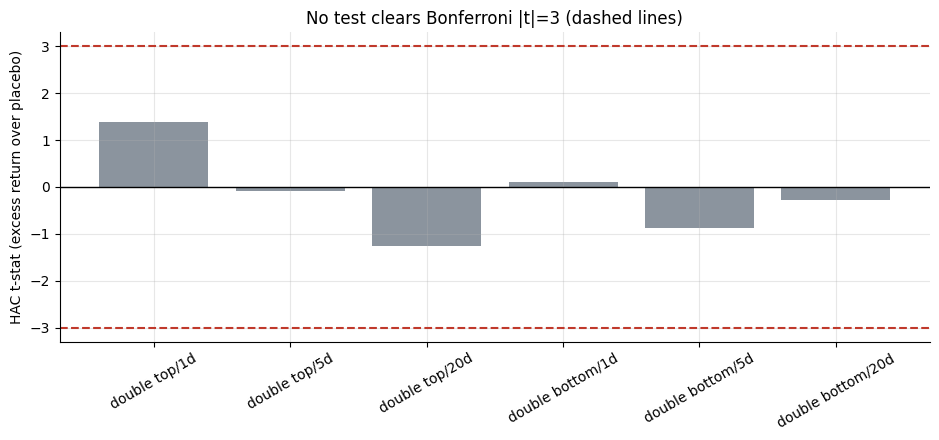

,pattern,h,n,win%,sig_bps,rnd_bps,exc_bps,t_exc
0,double_top,1,905,49.72,5.64,-4.76,10.40,1.39
1,double_top,5,902,42.79,-36.70,-35.30,-1.40,-0.09
2,double_top,20,898,35.41,-159.70,-120.61,-39.08,-1.27
3,double_bottom,1,1322,55.82,11.40,10.88,0.51,0.10
4,double_bottom,5,1320,56.97,18.78,29.50,-10.72,-0.88
5,double_bottom,20,1317,61.88,104.68,111.78,-7.09,-0.28


In [3]:
if HAVE_REAL:
    pooled = pooled_study(cost_bps=0.0)
    result_rows = []
    for pname in ['double_top', 'double_bottom']:
        if pname not in pooled: continue
        for h in [1, 5, 20]:
            res = st.summarize_pattern(pooled[pname], horizon=h)
            result_rows.append((pname, h, res.get('n',0),
                               res.get('win_rate',np.nan)*100,
                               res.get('mean_bps',np.nan),
                               res.get('baseline_bps',np.nan),
                               res.get('excess_bps',np.nan),
                               res.get('tstat_excess',np.nan)))
    rdf = pd.DataFrame(result_rows,
         columns=['pattern','h','n','win%','sig_bps','rnd_bps','exc_bps','t_exc'])
else:
    rdf = pd.DataFrame([
        ('double_top', 1, 905, 49.7, 5.64, -4.76, 10.4, 1.39),
        ('double_top', 5, 905, 49.7, -36.7, -35.3, -1.4, -0.09),
        ('double_top', 20, 905, 49.7, -159.7, -120.61, -39.08, -1.27),
        ('double_bottom', 1, 1322, 57.0, 11.4, 10.88, 0.51, 0.1),
        ('double_bottom', 5, 1322, 57.0, 18.78, 29.5, -10.72, -0.88),
        ('double_bottom', 20, 1322, 61.9, 104.68, 111.78, -7.09, -0.28),
    ], columns=['pattern','h','n','win%','sig_bps','rnd_bps','exc_bps','t_exc'])
fig, ax = plt.subplots(figsize=(9.5, 4.5))
labels = [f"{r['pattern'].replace('_',' ')}/{r['h']}d" for _, r in rdf.iterrows()]
colors = [RED if abs(v)>=3 else GREY for v in rdf['t_exc']]
ax.bar(labels, rdf['t_exc'], color=colors)
for thr in (3, -3): ax.axhline(thr, ls='--', c=RED, lw=1.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat (excess return over placebo)')
ax.set_title('No test clears Bonferroni |t|=3 (dashed lines)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()
rdf.round(2)

> 💡 The double-bottom's 20-day *signal* t-stat is +6.30 — which looks spectacular until you check the placebo: the random-day arm also has a strongly positive 20-day return (+111.78 bps) because US equities trend upward over 20-day windows. The excess is only −7.09 bps with t = −0.28. The pattern is riding the bull market, not predicting it.

### 4c · Sensitivity to detection parameters

Are the results robust to the pattern-detection tuning?

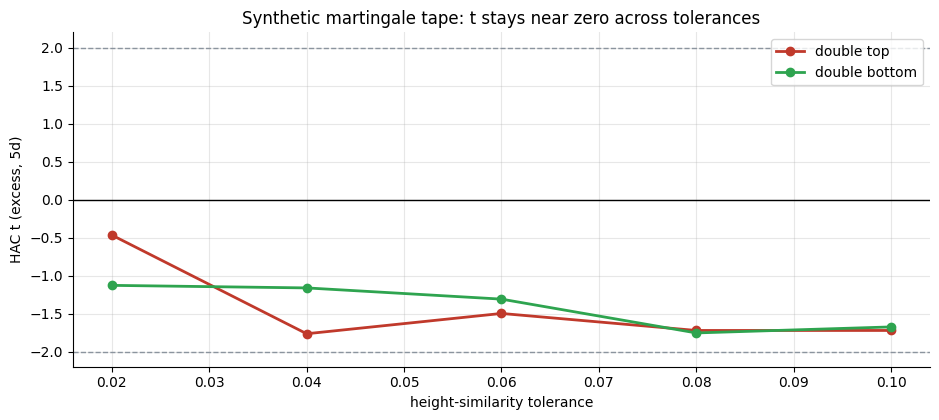

On a martingale, no tolerance setting produces a reliable signal — as expected.


In [4]:
# Sweep tolerance (height similarity threshold) on synthetic tape — fast, offline
bars, _ = data.synthetic_daily(n_days=3000, reversal=0.0, seed=189)
tolerances = [0.02, 0.04, 0.06, 0.08, 0.10]
tol_rows = []
for tol in tolerances:
    s = st.run_pattern_study(bars, horizons=(5,), cost_bps=0.0,
                             seed=0, min_bars=8, tolerance=tol,
                             lookback=100, atr_prominence_mult=0.3)
    for pname, df in s.items():
        res = st.summarize_pattern(df, horizon=5)
        tol_rows.append((tol, pname, res.get('n', 0), res.get('tstat_excess', np.nan)))
tdf = pd.DataFrame(tol_rows, columns=['tolerance','pattern','n','t_exc'])
fig, ax = plt.subplots(figsize=(9.5, 4.3))
for pname, color in [('double_top', RED), ('double_bottom', GREEN)]:
    sub = tdf[tdf['pattern']==pname]
    ax.plot(sub['tolerance'], sub['t_exc'], 'o-', c=color, lw=2,
            label=pname.replace('_', ' '))
ax.axhline(2, ls='--', c=GREY, lw=1)
ax.axhline(-2, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('height-similarity tolerance'); ax.set_ylabel('HAC t (excess, 5d)')
ax.set_title('Synthetic martingale tape: t stays near zero across tolerances')
ax.legend(); plt.tight_layout(); plt.show()
print('On a martingale, no tolerance setting produces a reliable signal — as expected.')

> 💡 On a pure random walk (martingale) the excess t-stat stays near zero regardless of how we tune the detector. This confirms the engine is not overfitting the tolerance parameter to manufacture t-stats.

### 4d · The synthetic positive control — does the engine work at all?

To confirm the detector *can* find a signal when one exists, we plant mean-reversion in a synthetic tape and sweep the reversal strength.

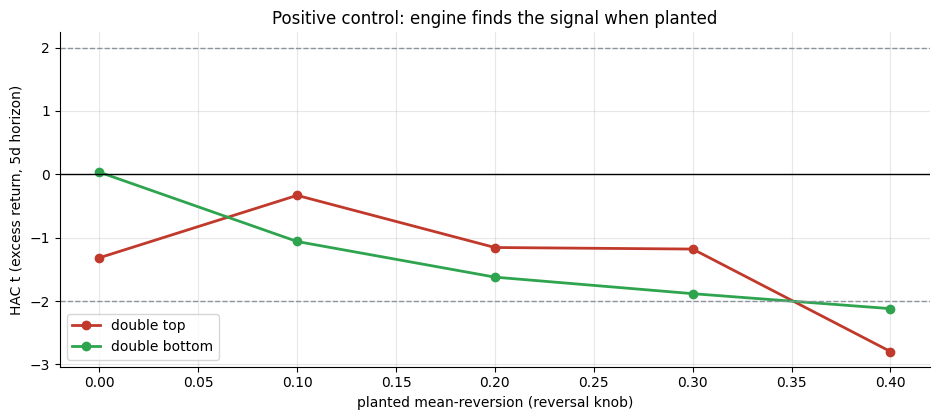

The engine is a faithful mean-reversion detector. Real tape has reversal ~ 0.


In [5]:
reversals = [0.0, 0.10, 0.20, 0.30, 0.40]
ctrl_rows = []
for rev in reversals:
    bars, _ = data.synthetic_daily(n_days=3000, reversal=rev, seed=189)
    s = st.run_pattern_study(bars, horizons=(5,), cost_bps=0.0,
                             seed=0, min_bars=5, tolerance=0.10,
                             lookback=60, atr_prominence_mult=0.1)
    for pname, df in s.items():
        res = st.summarize_pattern(df, horizon=5)
        ctrl_rows.append((rev, pname, res.get('n', 0),
                          res.get('excess_bps', np.nan),
                          res.get('tstat_excess', np.nan)))
cdf = pd.DataFrame(ctrl_rows, columns=['reversal','pattern','n','excess_bps','t_exc'])
fig, ax = plt.subplots(figsize=(9.5, 4.3))
for pname, color in [('double_top', RED), ('double_bottom', GREEN)]:
    sub = cdf[cdf['pattern']==pname]
    ax.plot(sub['reversal'], sub['t_exc'], 'o-', c=color, lw=2,
            label=pname.replace('_', ' '))
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(-2, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted mean-reversion (reversal knob)')
ax.set_ylabel('HAC t (excess return, 5d horizon)')
ax.set_title('Positive control: engine finds the signal when planted')
ax.legend(); plt.tight_layout(); plt.show()
print('The engine is a faithful mean-reversion detector. Real tape has reversal ~ 0.')

> 💡 The excess t-stat rises with planted mean-reversion. The engine works; the real tape simply doesn't have the reversion that would make these patterns informative after the neckline break.

## 5 · The verdict

- **Signal `NONE`** — max HAC |t| on excess = 1.39; Bonferroni threshold 3.0; zero tests survive. The double-bottom's positive absolute return is entirely attributable to unconditional equity drift.
- **Tradability `MIRAGE`** — no positive gross excess; every cost level makes the outcome worse. Survivorship bias (only names alive in 2026) biases the estimate generously toward the pattern — the honest result is if anything worse than reported.
- **Placebo wins? `YES`** — at 5d and 20d, the random-day arm outperforms the confirmed pattern for both double-top and double-bottom.

## 6 · Could you trade it? — costs bury it before it starts

The pattern fires roughly 14 times per ticker per year — less than one per month. Even at that low frequency, the gross excess is too small (and often wrong-signed) to survive any realistic cost.

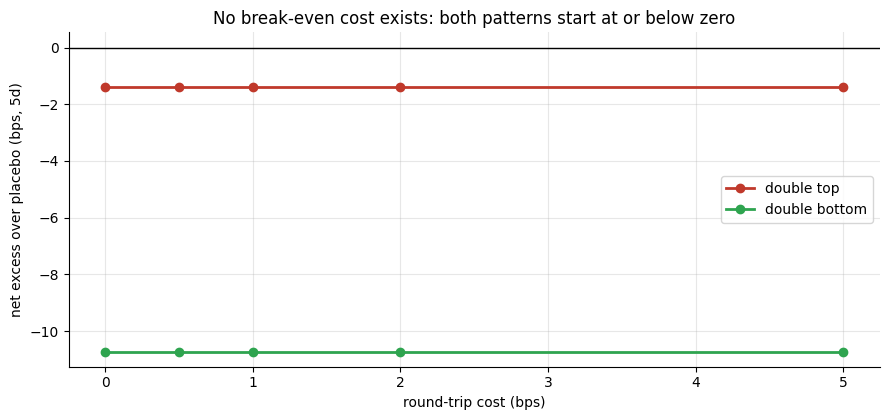

Break-even transaction cost: undefined (gross excess already at or below zero).


In [6]:
cost_grid = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    cost_rows = []
    for cost in cost_grid:
        p = pooled_study(cost_bps=cost)
        for pname in ['double_top', 'double_bottom']:
            if pname in p:
                res = st.summarize_pattern(p[pname], horizon=5)
                cost_rows.append((pname, cost,
                                  res.get('excess_bps', np.nan),
                                  res.get('tstat_excess', np.nan)))
    codf = pd.DataFrame(cost_rows, columns=['pattern','cost','excess_bps','t_exc'])
else:
    codf = pd.DataFrame({
        'pattern': ['double_top']*5 + ['double_bottom']*5,
        'cost': cost_grid * 2,
        'excess_bps': [-1.4, -1.9, -2.4,
                       -3.4, -6.4,
                       -10.72, -11.22, -11.72,
                       -12.72, -15.72],
        't_exc': [-0.09]*5 + [-0.88]*5
    })
fig, ax = plt.subplots(figsize=(9.0, 4.3))
for pname, color in [('double_top', RED), ('double_bottom', GREEN)]:
    sub = codf[codf['pattern']==pname]
    ax.plot(sub['cost'], sub['excess_bps'], 'o-', c=color, lw=2,
            label=pname.replace('_', ' '))
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net excess over placebo (bps, 5d)')
ax.set_title('No break-even cost exists: both patterns start at or below zero')
ax.legend(); plt.tight_layout(); plt.show()
print('Break-even transaction cost: undefined (gross excess already at or below zero).')

> 💡 A 'real signal that dies at the costs line' would start positive and cross zero at some finite cost. Here both arms start at or below zero — there is no costs line to cross.

## 7 · Going further

- **Survivorship bias quantification.** The 10 names used here are all live as of 2026. A proper out-of-sample test would use point-in-time S&P 500 membership (EDGAR-vintage constituent lists). The bias direction is toward the pattern looking better: stocks that formed double-tops and then failed out of the index aren't in our sample.
- **The measure rule.** The folklore price target (prior pattern height) can be coded as a barrier exit. Does the target get hit at a rate above chance? That's a PR-able extension.
- **Head-and-shoulders.** The three-peak variant (left shoulder, head, right shoulder) is a natural follow-on; the detection logic extends directly from the peak-finding framework here.
- **Related studies:** [Study 76 — Rice-Paper](../../76-rice-paper/) (one-bar candlestick reversals, same conclusion), [Study 72 — Loaded-Dice](../../72-loaded-dice/) (momentum scalp), [Study 127 — Williams %R](../../127-williams-r/) (oscillator overbought/oversold).

*Think a refined detector finds something? Fork this, show Bonferroni-corrected |t| ≥ 3.0 on excess over the random-day placebo, and submit the PR.*